# Part B - Predictive modeling

Module 2, Part B - predictive modeling, continuing from the saved titanic.csv.

Run all cells from inside `/analytics`, after `01_eda.ipynb`.
No sns.load_dataset call here: the data comes from titanic.csv written by 01_eda.ipynb.
Outputs: figures/*.png, best_pipeline.joblib, MODELING_REPORT.md

## Imports and helpers

In [1]:
from IPython.display import Markdown, display
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, mean_absolute_error,
                             mean_squared_error, precision_score, r2_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError as e:
    raise ImportError("Missing dependency: pip install imbalanced-learn") from e

SEED = 42
HERE = os.getcwd()  # run the notebook from inside /analytics
FIG = os.path.join(HERE, "figures")
os.makedirs(FIG, exist_ok=True)
report = []


def say(text=""):
    display(Markdown(text))  # renders the written interpretation as Markdown
    report.append(text)


def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, name), dpi=120)
    plt.show()
    plt.close()


def block(df, digits=3):
    return "```\n" + df.round(digits).to_string() + "\n```\n"

## setup + split

In [2]:
df = pd.read_csv(os.path.join(HERE, "titanic.csv"))
NUM = ["pclass", "age", "sibsp", "parch", "fare"]
CAT = ["sex", "embarked"]

say("# Titanic modeling report (generated by 02_modeling.ipynb)\n")
say("## Setup\n")
n0 = len(df)
df = df.dropna(subset=["embarked"]).reset_index(drop=True)
say(f"- Dropped {n0 - len(df)} rows with missing `embarked` (0.22% < 5%, so the threshold rule says drop). "
    "This uses no fitted statistic, so doing it before the split cannot leak.")
say("- `age` (19.87% missing) is imputed *inside* the pipeline with the training-set median. "
    "`deck` (77% missing) is left out of the models entirely.")
say("- Excluded on purpose: `alive` (a copy of the target, pure leakage), `class`/`embark_town` "
    "(duplicates of `pclass`/`embarked`), `who`/`adult_male`/`alone` (derived from other columns).")
say(f"- Features: numeric {NUM}, categorical {CAT}. Target: `survived`.\n")

X, y = df[NUM + CAT], df["survived"]
bal = y.value_counts(normalize=True).sort_index()
say(f"Class balance: not survived {bal[0]:.1%}, survived {bal[1]:.1%}.\n")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
say(f"Stratified 80/20 split (train {len(X_train)}, test {len(X_test)}). Stratification matters because "
    f"the classes are unbalanced ({bal[1]:.1%} positives): a plain random split could leave the test "
    "set with a noticeably different survival share, making recall/precision/AUC noisy and "
    "not comparable. Stratifying keeps the same ratio in both halves.\n")
say(f"Train survival share {y_train.mean():.3f}, test survival share {y_test.mean():.3f}.\n")


def make_pre(num=NUM, cat=CAT, drop=None):
    """All fitted steps live inside the pipeline, so they are only ever fit on the training split."""
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
    cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                         ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop))])
    return ColumnTransformer([("num", num_pipe, num), ("cat", cat_pipe, cat)])


def evaluate(pipe):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {"accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred),
            "auc": roc_auc_score(y_test, proba), "TN": tn, "FP": fp, "FN": fn, "TP": tp}, proba

# Titanic modeling report (generated by 02_modeling.ipynb)


## Setup


- Dropped 2 rows with missing `embarked` (0.22% < 5%, so the threshold rule says drop). This uses no fitted statistic, so doing it before the split cannot leak.

- `age` (19.87% missing) is imputed *inside* the pipeline with the training-set median. `deck` (77% missing) is left out of the models entirely.

- Excluded on purpose: `alive` (a copy of the target, pure leakage), `class`/`embark_town` (duplicates of `pclass`/`embarked`), `who`/`adult_male`/`alone` (derived from other columns).

- Features: numeric ['pclass', 'age', 'sibsp', 'parch', 'fare'], categorical ['sex', 'embarked']. Target: `survived`.


Class balance: not survived 61.8%, survived 38.2%.


Stratified 80/20 split (train 711, test 178). Stratification matters because the classes are unbalanced (38.2% positives): a plain random split could leave the test set with a noticeably different survival share, making recall/precision/AUC noisy and not comparable. Stratifying keeps the same ratio in both halves.


Train survival share 0.383, test survival share 0.382.


## three classifiers

## Three classifiers


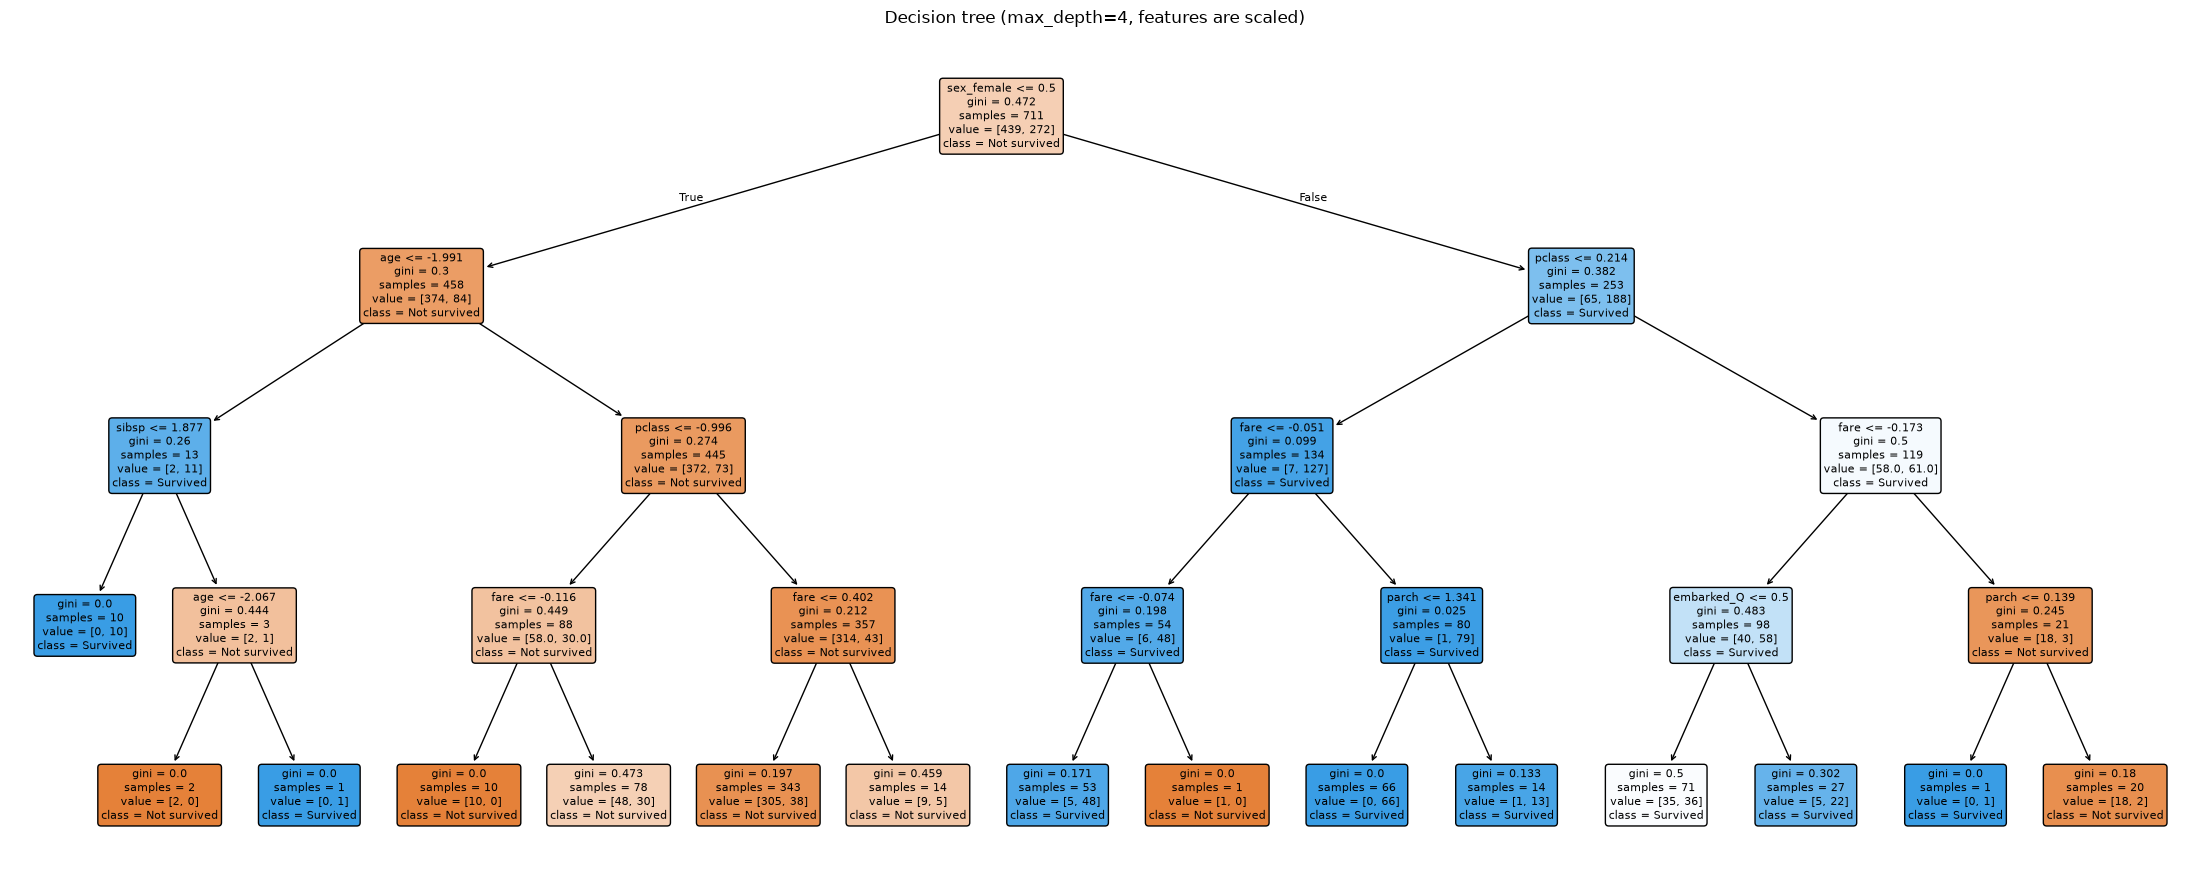

Decision tree rendered with `plot_tree` -> `figures/decision_tree.png` (depth limited to 4 so it stays readable and does not overfit).


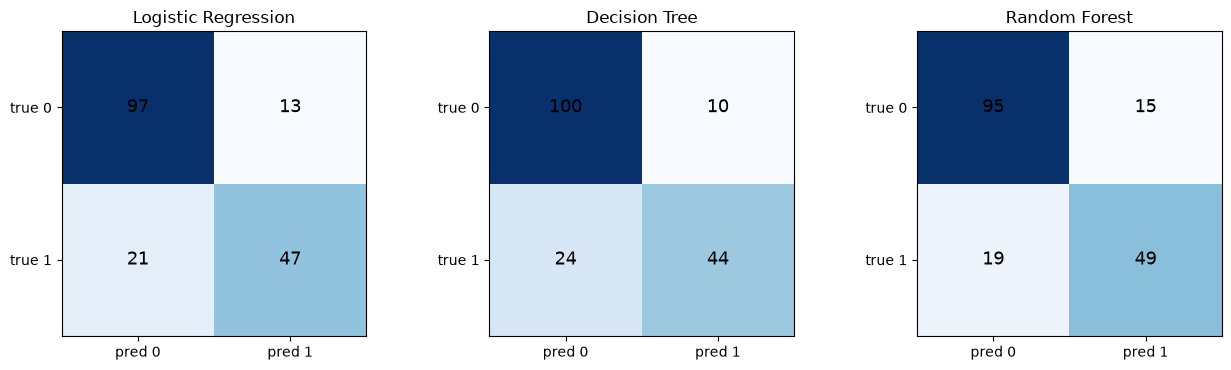

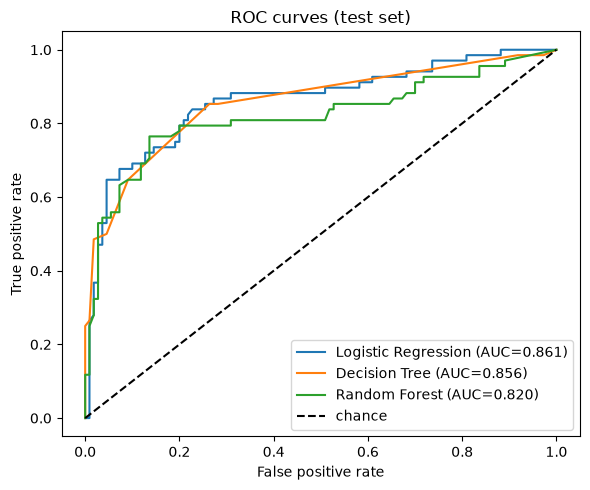

Side-by-side comparison on the test set (confusion-matrix counts included):


```
                     accuracy  precision  recall     f1    auc     TN    FP    FN    TP
Logistic Regression     0.809      0.783   0.691  0.734  0.861   97.0  13.0  21.0  47.0
Decision Tree           0.809      0.815   0.647  0.721  0.856  100.0  10.0  24.0  44.0
Random Forest           0.809      0.766   0.721  0.742  0.820   95.0  15.0  19.0  49.0
```


In [3]:
say("## Three classifiers\n")
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED),
}
fitted, rows, probas = {}, {}, {}
for name, est in models.items():
    pipe = Pipeline([("pre", make_pre()), ("clf", est)]).fit(X_train, y_train)
    fitted[name] = pipe
    rows[name], probas[name] = evaluate(pipe)

feat_names = [n.split("__")[-1] for n in fitted["Decision Tree"].named_steps["pre"].get_feature_names_out()]
plt.figure(figsize=(22, 9))
plot_tree(fitted["Decision Tree"].named_steps["clf"], feature_names=feat_names,
          class_names=["Not survived", "Survived"], filled=True, rounded=True, fontsize=8)
plt.title("Decision tree (max_depth=4, features are scaled)")
savefig("decision_tree.png")
say("Decision tree rendered with `plot_tree` -> `figures/decision_tree.png` "
    "(depth limited to 4 so it stays readable and does not overfit).\n")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, r) in zip(axes, rows.items()):
    cm = np.array([[r["TN"], r["FP"]], [r["FN"], r["TP"]]])
    ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, v, ha="center", va="center", fontsize=13)
    ax.set_xticks([0, 1], ["pred 0", "pred 1"])
    ax.set_yticks([0, 1], ["true 0", "true 1"])
    ax.set_title(name)
savefig("confusion_matrices.png")

plt.figure(figsize=(6, 5))
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={rows[name]['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.title("ROC curves (test set)")
savefig("roc_curves.png")

say("Side-by-side comparison on the test set (confusion-matrix counts included):\n")
say(block(pd.DataFrame(rows).T))

## imbalance

In [4]:
say("## Imbalance handling comparison (Logistic Regression)\n")
say(f"Class balance: not survived {bal[0]:.1%} / survived {bal[1]:.1%} "
    f"({(y == 0).sum()} vs {(y == 1).sum()} rows).\n")
variants = {
    "(a) baseline": Pipeline([("pre", make_pre()), ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]),
    "(b) class_weight='balanced'": Pipeline([("pre", make_pre()), ("clf", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED))]),
    # imblearn's Pipeline only resamples during fit, i.e. on the training data; test data is never touched
    "(c) SMOTE (train only)": ImbPipeline([("pre", make_pre()), ("smote", SMOTE(random_state=SEED)),
                                           ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]),
}
imb = {}
for name, pipe in variants.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    imb[name] = {"precision": precision_score(y_test, pred), "recall": recall_score(y_test, pred),
                 "f1": f1_score(y_test, pred)}
imb_df = pd.DataFrame(imb).T
say(block(imb_df))
best_imb = imb_df["f1"].idxmax()
spread = imb_df["f1"].max() - imb_df["f1"].min()
say(f"Conclusion: {best_imb} gave the best F1 ({imb_df.loc[best_imb, 'f1']:.3f}). "
    f"The F1 spread across the three strategies is only {spread:.3f}"
    + (f", so with a {bal[0]:.0%}/{bal[1]:.0%} split the imbalance is mild and none of the fixes is a clear win; "
       "balancing mainly trades some precision for recall."
       if spread < 0.03 else
       (", so no rebalancing was needed: the plain model already handles this class ratio best."
        if best_imb.startswith("(a)") else
        ", so rebalancing helped: the model catches more of the minority class without losing much precision."))
    + " SMOTE was applied only inside the training fit, so no synthetic points leaked into the test set.\n")

## Imbalance handling comparison (Logistic Regression)


Class balance: not survived 61.8% / survived 38.2% (549 vs 340 rows).


```
                             precision  recall     f1
(a) baseline                     0.783   0.691  0.734
(b) class_weight='balanced'      0.718   0.750  0.734
(c) SMOTE (train only)           0.735   0.735  0.735
```


Conclusion: (c) SMOTE (train only) gave the best F1 (0.735). The F1 spread across the three strategies is only 0.001, so with a 62%/38% split the imbalance is mild and none of the fixes is a clear win; balancing mainly trades some precision for recall. SMOTE was applied only inside the training fit, so no synthetic points leaked into the test set.


## tuning

In [5]:
say("## Random Forest hyperparameter tuning (GridSearchCV)\n")
rf_pipe = Pipeline([("pre", make_pre()),
                    ("clf", RandomForestClassifier(oob_score=True, random_state=SEED, n_jobs=1))])
grid = {"clf__n_estimators": [100, 200, 300], "clf__max_depth": [3, 5, 8, None],
        "clf__max_features": ["sqrt", "log2", None]}
gs = GridSearchCV(rf_pipe, grid, cv=5, scoring="f1", n_jobs=-1).fit(X_train, y_train)
oob = gs.best_estimator_.named_steps["clf"].oob_score_
say(f"Grid: {grid}\n")
say(f"Best params: `{gs.best_params_}`; best 5-fold CV F1 = {gs.best_score_:.3f}; "
    f"OOB score of the refit best forest = {oob:.3f}.\n")
fitted["Random Forest (tuned)"] = gs.best_estimator_
rows["Random Forest (tuned)"], probas["Random Forest (tuned)"] = evaluate(gs.best_estimator_)

## Random Forest hyperparameter tuning (GridSearchCV)


Grid: {'clf__n_estimators': [100, 200, 300], 'clf__max_depth': [3, 5, 8, None], 'clf__max_features': ['sqrt', 'log2', None]}


Best params: `{'clf__max_depth': 8, 'clf__max_features': None, 'clf__n_estimators': 200}`; best 5-fold CV F1 = 0.756; OOB score of the refit best forest = 0.828.


## regression

## Regression side-task: predict `fare`


Features: pclass, sex, age, sibsp, parch, embarked. `survived` is excluded because it is an outcome that is not known when a ticket is priced. Same preprocessing pattern (train-fit only); one-hot uses `drop='first'` to avoid perfect collinearity with the intercept.


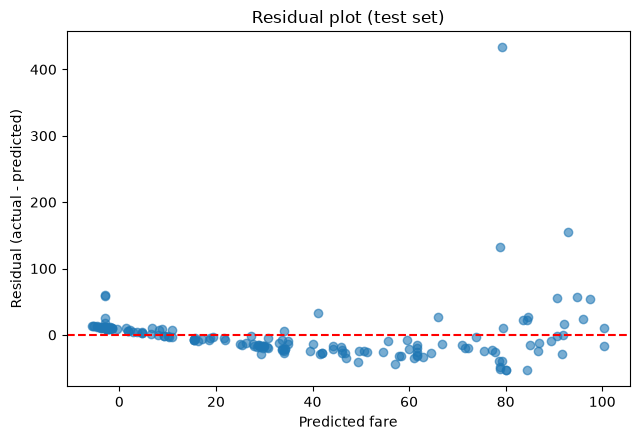

```
         value
MAE     21.140
RMSE    41.747
R2       0.347
Adj_R2   0.320
```


Adjusted R2 uses n = 178 test rows and p = 7 encoded predictors.


Residual check: Spearman correlation between |residual| and predicted fare is +0.52 (p = 1.36e-13); residual std is 13.2 for the lower half of predictions vs 56.9 for the upper half. Verdict: **heteroscedasticity present** - the residuals fan out as predicted fare rises, breaking the constant-variance assumption; fare is heavily right-skewed, so a log-transformed target would be a sensible next step.


In [6]:
say("## Regression side-task: predict `fare`\n")
say("Features: pclass, sex, age, sibsp, parch, embarked. `survived` is excluded because it is an outcome "
    "that is not known when a ticket is priced. Same preprocessing pattern (train-fit only); "
    "one-hot uses `drop='first'` to avoid perfect collinearity with the intercept.\n")
RNUM, RCAT = ["pclass", "age", "sibsp", "parch"], ["sex", "embarked"]
Xr, yr = df[RNUM + RCAT], df["fare"]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=SEED)
reg = Pipeline([("pre", make_pre(RNUM, RCAT, drop="first")), ("lr", LinearRegression())]).fit(Xr_tr, yr_tr)
pred_r = reg.predict(Xr_te)
n, p = len(yr_te), len(reg.named_steps["pre"].get_feature_names_out())
r2 = r2_score(yr_te, pred_r)
reg_metrics = {"MAE": mean_absolute_error(yr_te, pred_r),
               "RMSE": float(np.sqrt(mean_squared_error(yr_te, pred_r))),
               "R2": r2, "Adj_R2": 1 - (1 - r2) * (n - 1) / (n - p - 1)}
resid = yr_te - pred_r
plt.figure(figsize=(6.5, 4.5))
plt.scatter(pred_r, resid, alpha=0.6)
plt.axhline(0, color="red", ls="--")
plt.xlabel("Predicted fare")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot (test set)")
savefig("residual_plot.png")

rho, pval = spearmanr(pred_r, np.abs(resid))
order = np.argsort(pred_r)
lo_std, hi_std = resid.values[order[: n // 2]].std(), resid.values[order[n // 2:]].std()
hetero = pval < 0.05 and (hi_std / lo_std > 1.5 or hi_std / lo_std < 1 / 1.5)
say(block(pd.DataFrame(reg_metrics, index=["value"]).T, 3))
say(f"Adjusted R2 uses n = {n} test rows and p = {p} encoded predictors.\n")
say(f"Residual check: Spearman correlation between |residual| and predicted fare is {rho:+.2f} "
    f"(p = {pval:.3g}); residual std is {lo_std:.1f} for the lower half of predictions vs {hi_std:.1f} "
    f"for the upper half. Verdict: **{'heteroscedasticity present' if hetero else 'no strong heteroscedasticity'}** - "
    + ("the residuals fan out as predicted fare rises, breaking the constant-variance assumption; fare is "
       "heavily right-skewed, so a log-transformed target would be a sensible next step.\n"
       if hetero else "the spread of residuals looks roughly constant.\n"))

## comparison + recommendation

In [7]:
say("## Model comparison\n")
say("Classification models (test set) - metrics are bounded 0-1:\n")
say(block(pd.DataFrame(rows).T[["accuracy", "precision", "recall", "f1", "auc"]]))
say("Regression model (test set) - error metrics are in fare units (pounds), R2/Adj R2 are unitless. "
    "These two groups are on different scales and are NOT comparable with each other:\n")
say(block(pd.DataFrame(reg_metrics, index=["Linear Regression"])))

comp = pd.DataFrame(rows).T.sort_values(["auc", "f1"], ascending=False)
best_name, second = comp.index[0], comp.index[1]
b, s = comp.iloc[0], comp.iloc[1]
say("### Recommendation\n")
say(f"I would deploy **{best_name}**. It has the highest test AUC ({b['auc']:.3f}) with accuracy "
    f"{b['accuracy']:.3f}, precision {b['precision']:.3f}, recall {b['recall']:.3f} and F1 {b['f1']:.3f}. "
    f"The runner-up, {second}, reaches AUC {s['auc']:.3f} and F1 {s['f1']:.3f}. "
    f"With only {len(y_test)} test rows, gaps of a couple of points are within noise, so the choice is "
    "about simplicity and maintainability as well as raw score, so when scores are this close I favour the option that is easiest to explain and monitor. "
    f"The tuned forest's 5-fold CV F1 ({gs.best_score_:.3f}) and OOB score ({oob:.3f}) are in the same range "
    "as its test scores, which suggests the estimates are not badly overfit.\n")

## Model comparison


Classification models (test set) - metrics are bounded 0-1:


```
                       accuracy  precision  recall     f1    auc
Logistic Regression       0.809      0.783   0.691  0.734  0.861
Decision Tree             0.809      0.815   0.647  0.721  0.856
Random Forest             0.809      0.766   0.721  0.742  0.820
Random Forest (tuned)     0.826      0.825   0.691  0.752  0.837
```


Regression model (test set) - error metrics are in fare units (pounds), R2/Adj R2 are unitless. These two groups are on different scales and are NOT comparable with each other:


```
                     MAE    RMSE     R2  Adj_R2
Linear Regression  21.14  41.747  0.347    0.32
```


### Recommendation


I would deploy **Logistic Regression**. It has the highest test AUC (0.861) with accuracy 0.809, precision 0.783, recall 0.691 and F1 0.734. The runner-up, Decision Tree, reaches AUC 0.856 and F1 0.721. With only 178 test rows, gaps of a couple of points are within noise, so the choice is about simplicity and maintainability as well as raw score, so when scores are this close I favour the option that is easiest to explain and monitor. The tuned forest's 5-fold CV F1 (0.756) and OOB score (0.828) are in the same range as its test scores, which suggests the estimates are not badly overfit.


## save + reload

In [8]:
say("## Saved artifact\n")
best_pipe = fitted[best_name]
path = os.path.join(HERE, "best_pipeline.joblib")
joblib.dump(best_pipe, path)  # full pipeline: preprocessing + estimator
loaded = joblib.load(path)
same = np.array_equal(loaded.predict(X_test), best_pipe.predict(X_test))
acc = accuracy_score(y_test, loaded.predict(X_test))
new_passengers = pd.DataFrame([
    {"pclass": 1, "age": 29.0, "sibsp": 0, "parch": 0, "fare": 90.0, "sex": "female", "embarked": "C"},
    {"pclass": 3, "age": np.nan, "sibsp": 0, "parch": 0, "fare": 7.9, "sex": "male", "embarked": "S"},
])
new_pred = loaded.predict(new_passengers)
new_prob = loaded.predict_proba(new_passengers)[:, 1]
assert same
say(f"Saved `{best_name}` as one Pipeline (imputer + encoder + scaler + estimator) to `best_pipeline.joblib`. "
    f"After `joblib.load` on raw, unprocessed test rows: predictions identical to the in-memory model = {same}, "
    f"test accuracy = {acc:.3f}.\n")
say(f"Raw new-passenger check (second row has a missing age): predictions {new_pred.tolist()}, "
    f"survival probabilities {np.round(new_prob, 3).tolist()}.\n")

with open(os.path.join(HERE, "MODELING_REPORT.md"), "w", encoding="utf-8") as f:
    f.write("\n".join(report))
print("Wrote MODELING_REPORT.md")

## Saved artifact


Saved `Logistic Regression` as one Pipeline (imputer + encoder + scaler + estimator) to `best_pipeline.joblib`. After `joblib.load` on raw, unprocessed test rows: predictions identical to the in-memory model = True, test accuracy = 0.809.


Raw new-passenger check (second row has a missing age): predictions [1, 0], survival probabilities [0.949, 0.097].


Wrote MODELING_REPORT.md
